In [1]:
#import modules and load the data
import pandas as pd
import sklearn
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute


df = pd.read_csv("insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges  death
0      19  female  27.900         0    yes  southwest  16884.92400      0
1      18    male  33.770         1     no  southeast   1725.55230      0
2      28    male  33.000         3     no  southeast   4449.46200      0
3      33    male  22.705         0     no  northwest  21984.47061      0
4      32    male  28.880         0     no  northwest   3866.85520      0
...   ...     ...     ...       ...    ...        ...          ...    ...
1333   50    male  30.970         3     no  northwest  10600.54830      0
1334   18  female  31.920         0     no  northeast   2205.98080      0
1335   18  female  36.850         0     no  southeast   1629.83350      0
1336   21  female  25.800         0     no  southwest   2007.94500      0
1337   61  female  29.070         0    yes  northwest  29141.36030      0

[1338 rows x 8 columns]


In [2]:
from sklearn.preprocessing import MinMaxScaler

y= df['death'] #select Target
X = df.drop('death',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True)

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

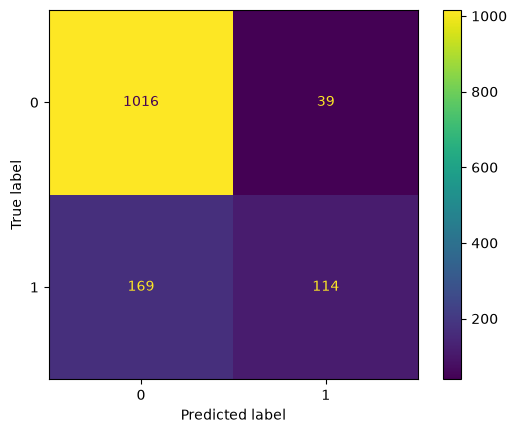

Accuracy: 0.8445440956651719
Precision: 0.7450980392156863
Recall: 0.4028268551236749
F1 Score: 0.5229357798165137


In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

logreg = LogisticRegression() #Define the logistic regression function
y_pred = cross_val_predict(logreg, X, y, cv=5) #make the prediction with 1383 folds

cm = confusion_matrix(y, y_pred) #Create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

#calculate metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

#print the metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)